In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.metrics import accuracy_score

In [ ]:
student_dataset = pd.read_csv("AI_Student_Life_Pakistan_2026.csv")
student_dataset

,Student_ID,Age,Gender,Education_Level,City,AI_Tool_Used,Daily_Usage_Hours,Purpose,Impact_on_Grades,Satisfaction_Level
0,1,15,Female,School,Lahore,ChatGPT,0.8,Writing,Slight Decline,Low
1,2,15,Female,College,Multan,Copilot,1.6,Learning,No Change,High
2,3,16,Female,College,Multan,ChatGPT,1.8,Research,Improved,Low
3,4,22,Male,University,Karachi,ChatGPT,4.2,Learning,Improved,High
4,5,16,Male,School,Multan,ChatGPT,1.8,Coding,Improved,Medium
...,...,...,...,...,...,...,...,...,...,...
95,96,16,Female,School,Multan,Grammarly,5.0,Learning,Slight Decline,Medium
96,97,25,Female,School,Faisalabad,Gemini,1.9,Writing,No Change,Medium
97,98,17,Female,College,Faisalabad,Gemini,2.9,Writing,No Change,Low
98,99,15,Female,College,Lahore,Notion AI,3.6,Homework,Slight Decline,High


Student_ID: ID unik yang digunakan untuk mengidentifikasi setiap siswa dalam dataset. Nilai ini bersifat unik dan tidak memiliki makna analitis.
Age: Usia siswa dalam satuan tahun. Variabel ini termasuk data numerik yang menunjukkan umur responden.
Gender: Jenis kelamin siswa, biasanya dikategorikan sebagai Male (laki-laki) atau Female (perempuan). Variabel ini termasuk data kategorik nominal.
Education_Level: Tingkat pendidikan siswa, seperti School, College, atau University. Variabel ini merupakan data kategorik ordinal karena memiliki tingkatan.
City: Kota tempat tinggal siswa, misalnya Lahore, Multan, Karachi, atau Faisalabad. Variabel ini termasuk data kategorik nominal.
AI_Tool_Used: Jenis alat kecerdasan buatan yang digunakan siswa, seperti ChatGPT, Copilot, Grammarly, Gemini, atau Notion AI. Variabel ini termasuk data kategorik nominal.
Daily_Usage_Hours: Rata-rata waktu penggunaan alat AI oleh siswa setiap hari dalam satuan jam. Variabel ini termasuk data numerik kontinu.
Purpose: Tujuan penggunaan AI oleh siswa, seperti Writing, Learning, Research, Coding, atau Homework. Variabel ini termasuk data kategorik nominal.
Impact_on_Grades: Dampak penggunaan AI terhadap nilai akademik siswa, seperti Improved, No Change, atau Slight Decline. Variabel ini termasuk data kategorik ordinal karena menunjukkan urutan tingkat dampak.
Satisfaction_Level: Tingkat kepuasan siswa terhadap penggunaan AI, seperti Low, Medium, atau High. Variabel ini termasuk data kategorik ordinal karena memiliki tingkatan kepuasan.

# Mengubah Target Menjadi Biner

In [ ]:
# Ubah target jadi biner
# Improved = 1, selain itu = 0
student_dataset['Impact_on_Grades'] = student_dataset['Impact_on_Grades'].apply(
    lambda x: 1 if x == 'Improved' else 0
)

In [ ]:
student_dataset['Impact_on_Grades'].value_counts()

,count
Impact_on_Grades,
0,61
1,39


# Cek Statistik

In [ ]:
student_dataset.describe()

,Student_ID,Age,Daily_Usage_Hours,Impact_on_Grades
count,100.000000,100.000000,100.000000,100.000000
mean,50.500000,19.380000,3.064000,0.390000
std,29.011492,3.296095,1.564862,0.490207
min,1.000000,15.000000,0.500000,0.000000
25%,25.750000,16.000000,1.800000,0.000000
50%,50.500000,19.000000,3.200000,0.000000
75%,75.250000,22.000000,4.300000,1.000000
max,100.000000,25.000000,5.900000,1.000000


In [ ]:
student_dataset_encoded = pd.get_dummies(student_dataset, drop_first=True)
student_dataset_encoded

,Student_ID,Age,Daily_Usage_Hours,Impact_on_Grades,Gender_Male,Education_Level_School,Education_Level_University,City_Islamabad,City_Karachi,City_Lahore,...,AI_Tool_Used_Copilot,AI_Tool_Used_Gemini,AI_Tool_Used_Grammarly,AI_Tool_Used_Notion AI,Purpose_Homework,Purpose_Learning,Purpose_Research,Purpose_Writing,Satisfaction_Level_Low,Satisfaction_Level_Medium
0,1,15,0.8,0,False,True,False,False,False,True,...,False,False,False,False,False,False,False,True,True,False
1,2,15,1.6,0,False,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
2,3,16,1.8,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
3,4,22,4.2,1,True,False,True,False,True,False,...,False,False,False,False,False,True,False,False,False,False
4,5,16,1.8,1,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,16,5.0,0,False,True,False,False,False,False,...,False,False,True,False,False,True,False,False,False,True
96,97,25,1.9,0,False,True,False,False,False,False,...,False,True,False,False,False,False,False,True,False,True
97,98,17,2.9,0,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,True,False
98,99,15,3.6,0,False,False,False,False,False,True,...,False,False,False,True,True,False,False,False,False,False


# Logistic Regression (Statsmodels)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
x = student_dataset_encoded.drop(columns="Impact_on_Grades")
y = student_dataset_encoded["Impact_on_Grades"]

In [ ]:
x = x.apply(pd.to_numeric, errors='coerce')

In [ ]:
x = x.fillna(0)

In [ ]:
x

,Student_ID,Age,Daily_Usage_Hours,Gender_Male,Education_Level_School,Education_Level_University,City_Islamabad,City_Karachi,City_Lahore,City_Multan,AI_Tool_Used_Copilot,AI_Tool_Used_Gemini,AI_Tool_Used_Grammarly,AI_Tool_Used_Notion AI,Purpose_Homework,Purpose_Learning,Purpose_Research,Purpose_Writing,Satisfaction_Level_Low,Satisfaction_Level_Medium
0,1,15,0.8,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,True,False
1,2,15,1.6,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False
2,3,16,1.8,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False
3,4,22,4.2,True,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False
4,5,16,1.8,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,16,5.0,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,False,True
96,97,25,1.9,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True
97,98,17,2.9,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,True,False
98,99,15,3.6,False,False,False,False,False,True,False,False,False,False,True,True,False,False,False,False,False


In [ ]:
y

,Impact_on_Grades
0,0
1,0
2,1
3,1
4,1
...,...
95,0
96,0
97,0
98,0


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=1
)
x_train

,Student_ID,Age,Daily_Usage_Hours,Gender_Male,Education_Level_School,Education_Level_University,City_Islamabad,City_Karachi,City_Lahore,City_Multan,AI_Tool_Used_Copilot,AI_Tool_Used_Gemini,AI_Tool_Used_Grammarly,AI_Tool_Used_Notion AI,Purpose_Homework,Purpose_Learning,Purpose_Research,Purpose_Writing,Satisfaction_Level_Low,Satisfaction_Level_Medium
67,68,19,4.2,True,True,False,False,False,False,True,False,False,True,False,True,False,False,False,False,True
99,100,24,2.7,False,True,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False
54,55,17,1.9,False,True,False,False,False,False,True,False,False,True,False,False,False,True,False,False,True
95,96,16,5.0,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,False,True
88,89,15,5.0,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,76,23,2.0,True,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,True
9,10,21,3.6,True,False,False,False,False,True,False,False,False,True,False,False,False,False,True,True,False
72,73,15,4.7,True,False,True,False,False,False,False,False,False,False,True,True,False,False,False,True,False
12,13,20,0.7,True,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False


In [ ]:
x_test

,Student_ID,Age,Daily_Usage_Hours,Gender_Male,Education_Level_School,Education_Level_University,City_Islamabad,City_Karachi,City_Lahore,City_Multan,AI_Tool_Used_Copilot,AI_Tool_Used_Gemini,AI_Tool_Used_Grammarly,AI_Tool_Used_Notion AI,Purpose_Homework,Purpose_Learning,Purpose_Research,Purpose_Writing,Satisfaction_Level_Low,Satisfaction_Level_Medium
80,81,25,0.6,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,True
84,85,25,1.7,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False
33,34,15,3.6,True,False,True,True,False,False,False,False,True,False,False,False,False,True,False,False,False
81,82,16,4.7,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True
93,94,21,3.9,False,True,False,True,False,False,False,False,False,True,False,True,False,False,False,True,False
17,18,22,4.9,True,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False
36,37,15,4.3,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False
82,83,23,1.9,True,False,True,False,False,False,True,False,True,False,False,True,False,False,False,True,False
69,70,16,1.0,True,True,False,False,False,False,True,False,False,False,True,True,False,False,False,False,True
65,66,23,0.6,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=1
)

x_train = x_train.astype(float)
y_train = y_train.astype(float)

x_train_sm = sm.add_constant(x_train)

model = sm.Logit(y_train, x_train_sm)
model_result = model.fit()

model_result.summary()

Optimization terminated successfully.
         Current function value: 0.430357
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       Impact_on_Grades   No. Observations:                   70
Model:                          Logit   Df Residuals:                       49
Method:                           MLE   Df Model:                           20
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                  0.3477
Time:                        13:55:47   Log-Likelihood:                -30.125
converged:                       True   LL-Null:                       -46.180
Covariance Type:            nonrobust   LLR p-value:                   0.04214
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -9.1844      4.441     -2.068      0.039     -17.889      -0.480
Student_ID                     0.0103      0.015      0.700      0.484      -0.019       0.039
Age                            0.2183      0.134      1.635      0.102      -0.043       0.480
Daily_Usage_Hours              0.5977      0.306      1.953      0.051      -0.002       1.197
Gender_Male                    1.2935      0.851      1.521      0.128      -0.374       2.961
Education_Level_School         2.8046      1.098      2.553      0.011       0.652       4.958
Education_Level_University     3.4217      1.294      2.644      0.008       0.885       5.958
City_Islamabad                 0.5962      1.525      0.391      0.696      -2.392       3.585
City_Karachi                  -0.7631      1.427     -0.535      0.593      -3.559       2.033
City_Lahore                    2.7015      1.458      1.853      0.064      -0.155       5.558
City_Multan                    2.5334      1.441      1.759      0.079      -0.290       5.357
AI_Tool_Used_Copilot          -3.6421      1.632     -2.232      0.026      -6.840      -0.444
AI_Tool_Used_Gemini           -0.8908      1.128     -0.790      0.430      -3.101       1.319
AI_Tool_Used_Grammarly        -3.2029      1.273     -2.515      0.012      -5.699      -0.707
AI_Tool_Used_Notion AI         0.0608      1.157      0.053      0.958      -2.207       2.329
Purpose_Homework              -1.2005      1.048     -1.145      0.252      -3.256       0.854
Purpose_Learning              -0.4530      1.175     -0.386      0.700      -2.755       1.849
Purpose_Research              -1.4442      1.201     -1.202      0.229      -3.799       0.911
Purpose_Writing               -2.2874      1.730     -1.322      0.186      -5.679       1.104
Satisfaction_Level_Low         0.0695      0.962      0.072      0.942      -1.817       1.956
Satisfaction_Level_Medium      0.1766      0.926      0.191      0.849      -1.638       1.991
==============================================================================================
"""

In [ ]:
x_test = x_test.astype(float)

pred = model_result.predict(sm.add_constant(x_test))
pred = np.where(pred <= 0.5, 0, 1)
pred

array([1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 0])

np.where(pred <= 0.5, 0, 1) digunakan untuk mengonversi hasil prediksi probabilitas menjadi kelas biner (0 atau 1). Jika nilai probabilitas kurang dari atau sama dengan 0,5 maka dikategorikan sebagai 0, yang menunjukkan bahwa penggunaan AI tidak memberikan dampak peningkatan terhadap nilai siswa (misalnya No Change atau Slight Decline). Sebaliknya, jika nilai probabilitas lebih dari 0,5 maka dikategorikan sebagai 1, yang menunjukkan bahwa penggunaan AI memberikan dampak peningkatan terhadap nilai siswa (Improved).

In [ ]:
x_test = x_test.astype(float)
x_test_sm = sm.add_constant(x_test)

pred = model_result.predict(x_test_sm)
pred = np.where(pred <= 0.5, 0, 1)

accuracy_score(y_test, pred) * 100

70.0

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.7
[[14  3]
 [ 6  7]]
              precision    recall  f1-score   support

           0       0.70      0.82      0.76        17
           1       0.70      0.54      0.61        13

    accuracy                           0.70        30
   macro avg       0.70      0.68      0.68        30
weighted avg       0.70      0.70      0.69        30



In [ ]:
accuracy_score(y_test, pred) * 100

70.0

# Logistic Regression (Sklearn)

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(x_train, y_train)

pred = logistic_model.predict(x_test)
pred

accuracy_score(y_test, pred) * 100

63.33333333333333

In [ ]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
pred = logistic_model.predict(x_test)
pred

array([1., 0., 0., 0., 0., 1., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0.])

In [ ]:
x_test1 = x_test.copy()
x_test1['Prediksi'] = pred
x_test1['Aktual'] = y_test

x_test1

,Student_ID,Age,Daily_Usage_Hours,Gender_Male,Education_Level_School,Education_Level_University,City_Islamabad,City_Karachi,City_Lahore,City_Multan,...,AI_Tool_Used_Grammarly,AI_Tool_Used_Notion AI,Purpose_Homework,Purpose_Learning,Purpose_Research,Purpose_Writing,Satisfaction_Level_Low,Satisfaction_Level_Medium,Prediksi,Aktual
80,81.0,25.0,0.6,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1
84,85.0,25.0,1.7,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
33,34.0,15.0,3.6,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1
81,82.0,16.0,4.7,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
93,94.0,21.0,3.9,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1
17,18.0,22.0,4.9,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1
36,37.0,15.0,4.3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
82,83.0,23.0,1.9,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0
69,70.0,16.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0
65,66.0,23.0,0.6,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0


In [ ]:
accuracy_score(y_test, pred) * 100

63.33333333333333

# KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(x_train, y_train)


KNeighborsClassifier(n_neighbors=7)

In [ ]:
y_pred = knn_model.predict(x_test)

accuracy_score(y_test, y_pred) * 100

53.333333333333336

In [ ]:
y_pred

array([1., 1., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 1., 1., 1.,
       0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0.])

In [ ]:
neighbors_list = [1, 3, 5, 7, 9, 11]
train_accuracy_list, test_accuracy_list = [], []

for neighbor_num in neighbors_list:
    knn_model = KNeighborsClassifier(n_neighbors=neighbor_num)
    knn_model.fit(x_train, y_train)

    train_pred = knn_model.predict(x_train)
    test_pred = knn_model.predict(x_test)

    train_acc_score = accuracy_score(y_train, train_pred) * 100
    test_acc_score = accuracy_score(y_test, test_pred) * 100

    train_accuracy_list.append(train_acc_score)
    test_accuracy_list.append(test_acc_score)

    print("Neighbors_num: {} --> Accuracy on Test Set: {} %".format(
        neighbor_num, np.round(test_acc_score, 2)
    ))

Neighbors_num: 1 --> Accuracy on Test Set: 50.0 %
Neighbors_num: 3 --> Accuracy on Test Set: 53.33 %
Neighbors_num: 5 --> Accuracy on Test Set: 50.0 %
Neighbors_num: 7 --> Accuracy on Test Set: 53.33 %
Neighbors_num: 9 --> Accuracy on Test Set: 43.33 %
Neighbors_num: 11 --> Accuracy on Test Set: 50.0 %


In [ ]:
performance_df = pd.DataFrame({
    'Neighbors_num': neighbors_list,
    'Train Accuracy': train_accuracy_list,
    'Test Accuracy': test_accuracy_list
})

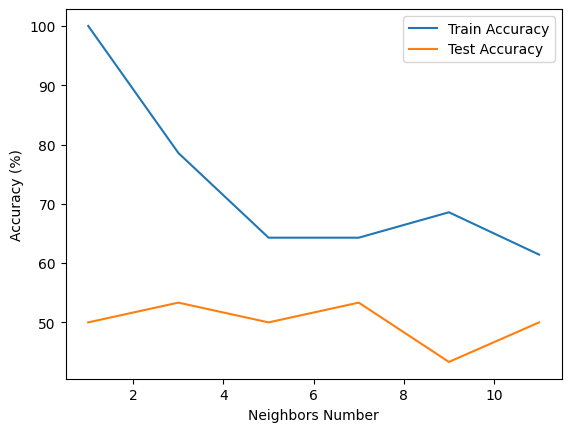

In [ ]:
plt.plot(
    performance_df['Neighbors_num'], performance_df['Train Accuracy'],
    performance_df['Neighbors_num'], performance_df['Test Accuracy']
)
plt.xlabel("Neighbors Number")
plt.ylabel("Accuracy (%)")
plt.legend(['Train Accuracy', 'Test Accuracy'])
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[11  6]
 [ 8  5]]
              precision    recall  f1-score   support

           0       0.58      0.65      0.61        17
           1       0.45      0.38      0.42        13

    accuracy                           0.53        30
   macro avg       0.52      0.52      0.51        30
weighted avg       0.53      0.53      0.53        30



# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import preprocessing

In [ ]:
classifier = DecisionTreeClassifier()
classifier.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = classifier.predict(x_test)

In [ ]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[13  4]
 [ 7  6]]
              precision    recall  f1-score   support

           0       0.65      0.76      0.70        17
           1       0.60      0.46      0.52        13

    accuracy                           0.63        30
   macro avg       0.62      0.61      0.61        30
weighted avg       0.63      0.63      0.62        30



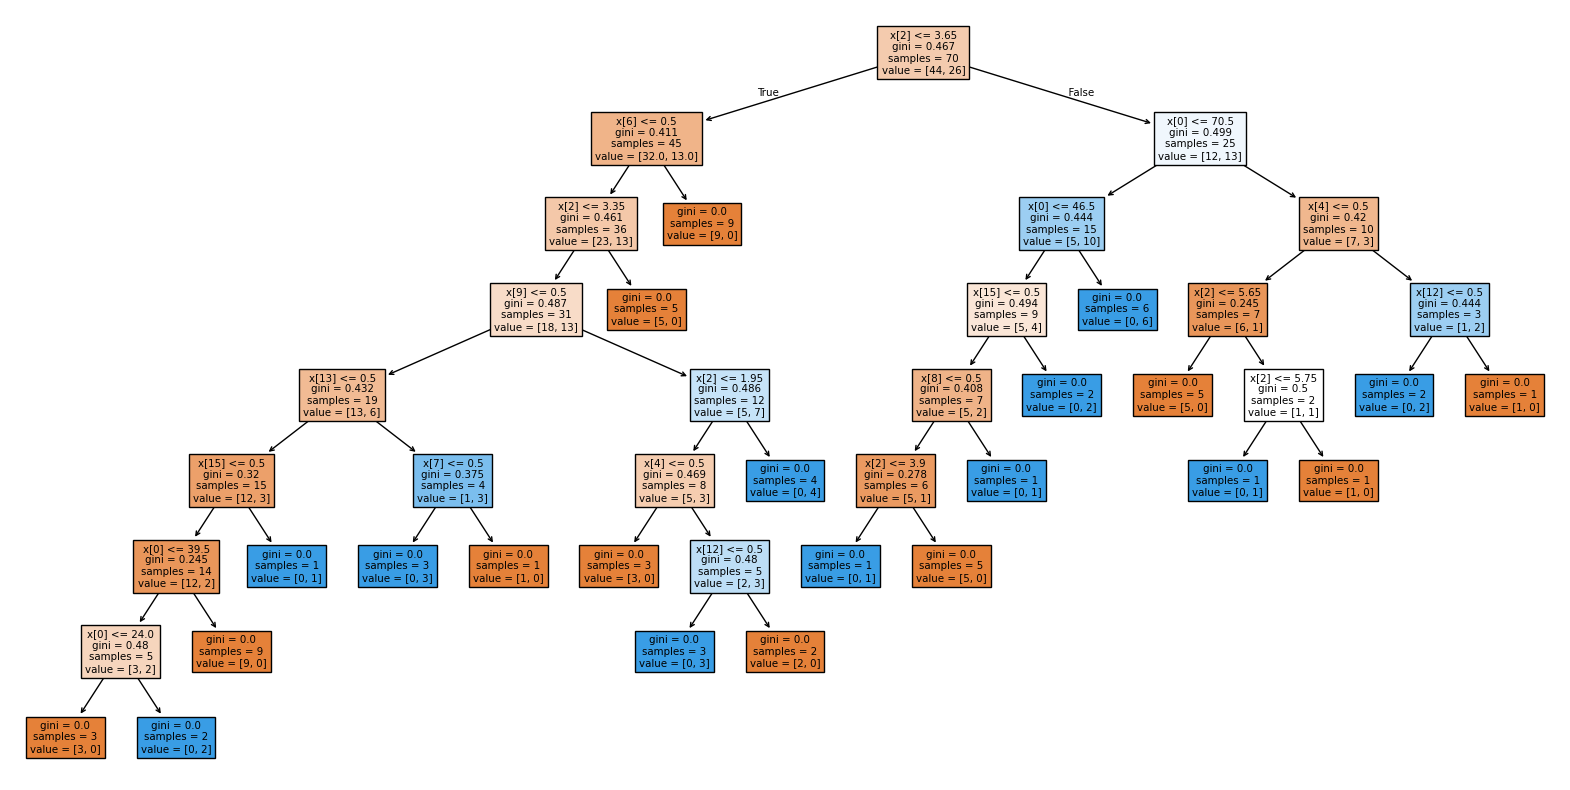

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(classifier, filled=True)
plt.show()

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(random_state=0)
rfc.fit(x_train, y_train)

RandomForestClassifier(random_state=0)

In [ ]:
y_pred = rfc.predict(x_test)
y_pred

array([1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])

In [ ]:
print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.5333333333333333


In [ ]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with 10 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with 10 decision-trees : 0.5333


In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

max_depth_tree_list = np.arange(1, 20, 2)

tree_params_list = {
    'max_depth': max_depth_tree_list,
    'criterion': ['gini', 'entropy']
}

In [ ]:
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=tree_params_list,
    cv=StratifiedKFold(n_splits=3),
    scoring='precision'
)

grid_search.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=None, shuffle=False),
             estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19])},
             scoring='precision')

In [ ]:
grid_search.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=np.int64(7))

In [ ]:
best_model = grid_search.best_estimator_

In [ ]:
y_best = best_model.predict(x_test)
y_best

array([1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 1., 1., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [ ]:
print(confusion_matrix(y_test, y_best))
print(classification_report(y_test, y_best))

[[14  3]
 [ 9  4]]
              precision    recall  f1-score   support

           0       0.61      0.82      0.70        17
           1       0.57      0.31      0.40        13

    accuracy                           0.60        30
   macro avg       0.59      0.57      0.55        30
weighted avg       0.59      0.60      0.57        30



In [ ]:
y_pred_rf = rfc.predict(x_test)
acc_rf = accuracy_score(y_test, y_pred_rf) * 100
acc_rf

53.333333333333336

# Support Vector Machine (SVM)

In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn import svm

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_model = svm.SVC()

parameter = {
    'kernel': ['linear', 'poly', 'rbf'],
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 10],
    'gamma': [0.0001, 0.001, 0.01, 0.1, 1]
}

grid = GridSearchCV(svm_model, parameter, cv=cv, scoring='accuracy')
grid

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=SVC(),
             param_grid={'C': [0.0001, 0.001, 0.01, 0.1, 1, 10],
                         'gamma': [0.0001, 0.001, 0.01, 0.1, 1],
                         'kernel': ['linear', 'poly', 'rbf']},
             scoring='accuracy')

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_model = svm.SVC()

parameter = {
    'kernel': ['linear', 'poly', 'rbf'],
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 10],
    'gamma': [0.0001, 0.001, 0.01, 0.1, 1]
}

grid = GridSearchCV(svm_model, parameter, cv=cv, scoring='accuracy')
grid.fit(x_train, y_train)

print("Best Parameter:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameter: {'C': 1, 'gamma': 0.0001, 'kernel': 'linear'}
Best Score: 0.6428571428571429


In [ ]:
from sklearn import svm
svm_model = svm.SVC(C=1, gamma=0.1, kernel='linear')

svm_model.fit(x_train, y_train)

SVC(C=1, gamma=0.1, kernel='linear')

In [ ]:
y_pred = svm_model.predict(x_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

acc_svm = accuracy_score(y_test, y_pred) * 100
print("Accuracy SVM:", acc_svm)

[[14  3]
 [ 7  6]]
              precision    recall  f1-score   support

           0       0.67      0.82      0.74        17
           1       0.67      0.46      0.55        13

    accuracy                           0.67        30
   macro avg       0.67      0.64      0.64        30
weighted avg       0.67      0.67      0.65        30

Accuracy SVM: 66.66666666666666


In [ ]:
from sklearn import svm

svm_model = svm.SVC(C=1, gamma=0.1, kernel='linear')

svm_model.fit(x, y)
y_pred = svm_model.predict(x)

y_pred

array([0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1])

In [ ]:
from sklearn import svm
from sklearn.model_selection import StratifiedKFold

svm_model = svm.SVC(C=1, gamma=0.1, kernel='linear')

svm_model.fit(x_train, y_train)

y_pred = svm_model.predict(x_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[14  3]
 [ 7  6]]
              precision    recall  f1-score   support

           0       0.67      0.82      0.74        17
           1       0.67      0.46      0.55        13

    accuracy                           0.67        30
   macro avg       0.67      0.64      0.64        30
weighted avg       0.67      0.67      0.65        30



In [ ]:
y_pred_svm = svm_model.predict(x_test)
acc_svm = accuracy_score(y_test, y_pred_svm) * 100
acc_svm

66.66666666666666